In [1]:
import sys
sys.path.append(r'../')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from src.d_CSL import GcStar
from src.dataload import *
# from tqdm.notebook import tqdm

No GPU automatically detected. Setting SETTINGS.GPU to 0, and SETTINGS.NJOBS to cpu_count.


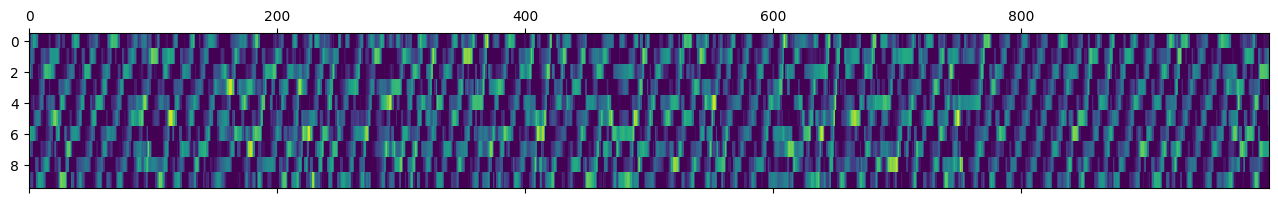

In [2]:
A = np.load('data/Lorenz96/GC_lorenz.npy')
X = np.load('data/Lorenz96/lorenz.npy')
X = X.T
plt.matshow(X, aspect='auto',vmin=0)

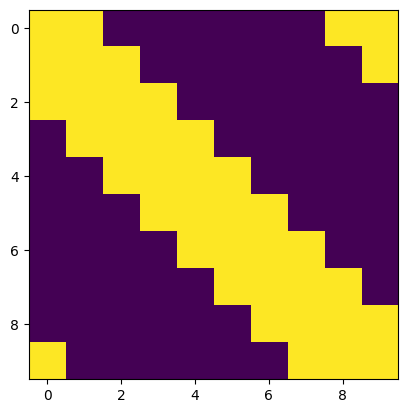

In [3]:
plt.imshow(A!=0)

In [4]:
def plott_(inferred,n_past,A):
    nn,n_neur = n_past+1,A.shape[0]
    fig, axs = plt.subplots(1,nn,figsize=(3.5*nn,3.5*nn))
    b = 0
    for a in range(nn):
        jj  = inferred[a*n_neur:(a+1)*n_neur,b*n_neur:(b+1)*n_neur]
        if a == 1:
            axs[a].imshow(mat_func(A,jj))
        else:
            axs[a].imshow(jj)
        axs[a].axis('off')
    plt.tight_layout()

def plot_(inferred,n_past,A):
    nn,n_neur = n_past+1,A.shape[0]
    fig, axs = plt.subplots(1,nn,figsize=(3.5*nn,3.5))
    b = 0
    for a in range(nn):
        jj  = inferred[a*n_neur:(a+1)*n_neur,b*n_neur:(b+1)*n_neur]
        axs[a].imshow(jj)
        axs[a].axis('off')
    plt.tight_layout()

def mat_func(A, inf):
    return (40 * np.logical_and(A != 0, inf != 0) +
                30 * np.logical_and(A == 0, inf != 0) +
                20 * np.logical_and(A != 0, inf == 0) +
                10 * np.logical_and(A == 0, inf == 0))

def apr_metrics(confusion_matrix):
    confusion_matrix = confusion_matrix.flatten()
    accuracy = (confusion_matrix[0] + confusion_matrix[3])/(np.sum(confusion_matrix))
    precision = confusion_matrix[0]/(confusion_matrix[0]+confusion_matrix[1])
    recall = confusion_matrix[0]/(confusion_matrix[0]+confusion_matrix[2])
    FPR = confusion_matrix[1]/(confusion_matrix[1]+confusion_matrix[3])
    return np.array([accuracy, precision, recall, FPR])

### Analysis

In [5]:
n_neur,n_perm,alpha,beta,N_PASTS = X.shape[0],1000,0.01,0.001,list(range(1, 5)) 
# n_lags = list(range(1, 3)) 

### With d_CSL algorithm

In [6]:
%%time
    
# Analysis
infs_fgc = []
conf_mtx_fgc = []
shds_fgc = []
shids_fgc = []
for a, n in enumerate(N_PASTS):
    print(f'{n} pasts')
    gcstar = GcStar(n_perm = 1000, 
                n_pasts = n, 
                n_lags = 1,
                temporal = True,
                method = 'fcgc')

    gcstar.fit(X, verbose = 0)
    inf = gcstar.get_connectivity_matrix(alpha, beta, simulation=False)   # 
    infs_fgc.append(inf)
    conf = gcstar.compute_confusion_matrix(A)
    conf_mtx_fgc.append(conf)
    shd = gcstar.compute_shd_sid(A, inf)
    shds_fgc.append(shd)
    sh, sd = gcstar.compute_SHD(A, inf), gcstar.compute_SID(A, inf)
    shids_fgc.append([sh,sd])
print('')

1 pasts
2 pasts
3 pasts
4 pasts


CPU times: user 2min 11s, sys: 32.2 s, total: 2min 43s
Wall time: 51.6 s


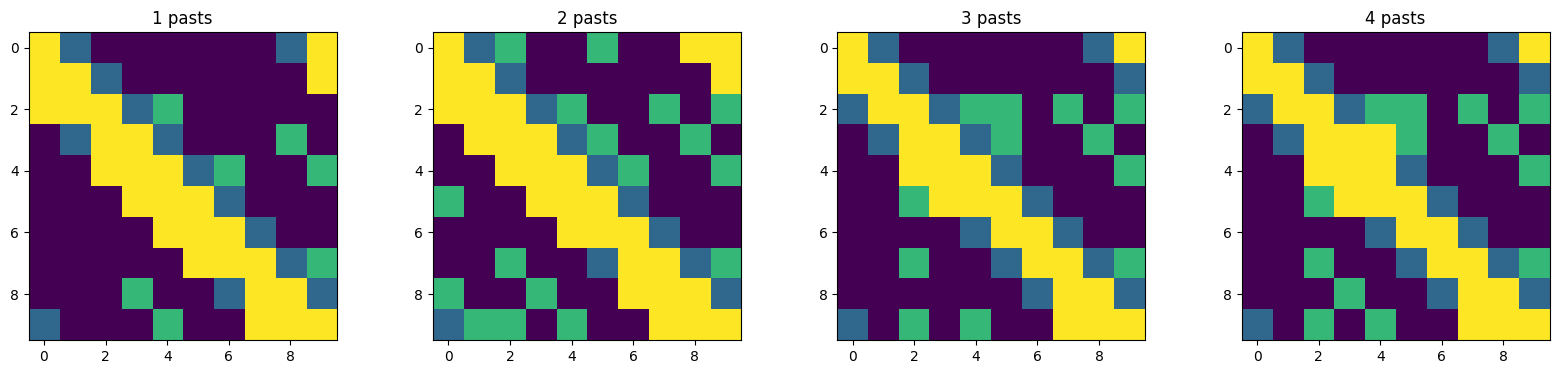

In [7]:
fig, axes = plt.subplots(1,len(infs_fgc), figsize=(20,4)) 
for i, ax in enumerate(axes):
    ax.imshow(mat_func(A,infs_fgc[i]))
    ax.set_title(f'{i+1} pasts')

In [8]:
metrics_fgc = []
for el in conf_mtx_fgc:
    metrics_fgc.append(apr_metrics(el))     
metrics_fgc

[array([0.8       , 0.79411765, 0.675     , 0.11666667]),
 array([0.72      , 0.63043478, 0.725     , 0.28333333]),
 array([0.71      , 0.65714286, 0.575     , 0.2       ]),
 array([0.71      , 0.64864865, 0.6       , 0.21666667])]

In [9]:
print(shds_fgc)
shids_fgc

[21.122673124861933, 22.638545313227024, 22.195477179652777, 22.48620544305068]


[[28.063170096073904, 90],
 [31.35553657442739, 90],
 [28.49656373732397, 90],
 [28.70252349350947, 90]]

## Granger Causality Adaptation

In [10]:
%%time
    
# Analysis
infs_gc = []
conf_mtx_gc = []
shds_gc = []
shids_gc = []
for a, n in enumerate(N_PASTS):
    print(f'{n} pasts')
    gcstar = GcStar(n_perm = 1000, 
                n_pasts = n, 
                n_lags = 1,
                temporal = True,
                method = 'cgc')

    gcstar.fit(X, verbose = 0)
    inf = gcstar.get_connectivity_matrix(alpha=0.01, beta=0.001, simulation=False)   # 
    infs_gc.append(inf)
    conf = gcstar.compute_confusion_matrix(A)
    conf_mtx_gc.append(conf)
    shd = gcstar.compute_shd_sid(A, inf)
    shds_gc.append(shd)
    sh, sd = gcstar.compute_SHD(A, inf), gcstar.compute_SID(A, inf)
    shids_gc.append([sh,sd])
print('')

1 pasts
2 pasts
3 pasts
4 pasts


CPU times: user 2min 1s, sys: 32.1 s, total: 2min 33s
Wall time: 43.3 s


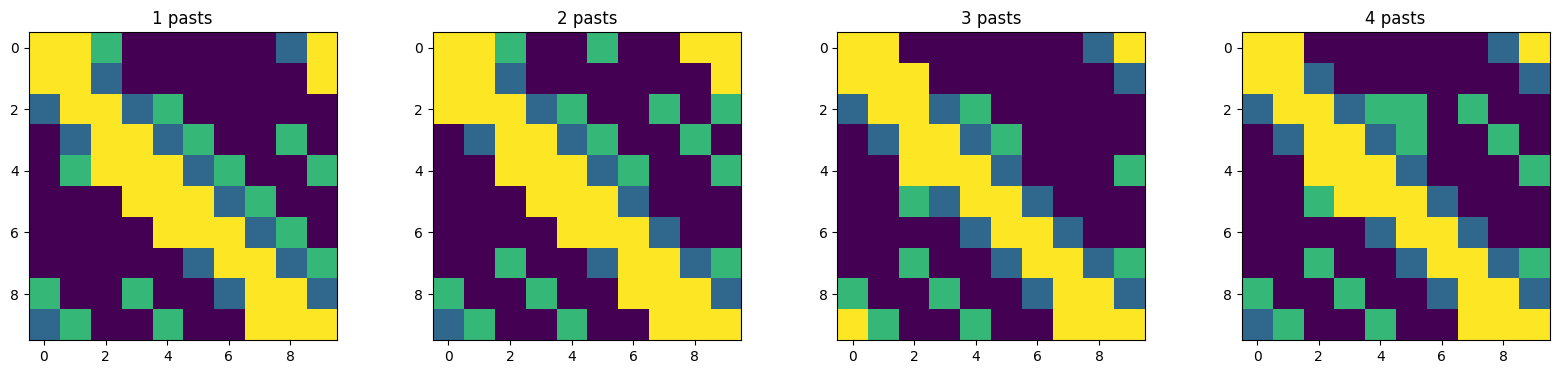

In [11]:
fig, axes = plt.subplots(1,len(infs_gc), figsize=(20,4)) 
for i, ax in enumerate(axes):
    ax.imshow(mat_func(A,infs_gc[i]))
    ax.set_title(f'{i+1} pasts')

In [12]:
metrics_gc = []
for el in conf_mtx_gc:
    metrics_gc.append(apr_metrics(el))     
metrics_gc

[array([0.72      , 0.65      , 0.65      , 0.23333333]),
 array([0.74      , 0.65909091, 0.725     , 0.25      ]),
 array([0.75      , 0.71428571, 0.625     , 0.16666667]),
 array([0.71      , 0.64864865, 0.6       , 0.21666667])]

In [13]:
print(shds_gc)
shids_gc

[20.074938365843774, 22.20991335957028, 20.344487184945017, 21.490922826464505]


[[29.776071451509615, 90],
 [30.169297795805956, 90],
 [27.471607443177213, 90],
 [29.05625585763115, 90]]